<a href="https://colab.research.google.com/github/scalabrinig/cdProjetoAplicadoIV/blob/master/projeto/cd_projeto_aplicado_IV_entrega_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

  <img src="https://raw.githubusercontent.com/scalabrinig/cdProjetoAplicadoIV/d093146488f56dfcf0ef286bcee8efe0e71b9c76/figuras/mackenzie_logo.jpg" width="25%" align="right"/>

# **PROJETO APLICADO IV - Ciência de Dados EaD - 2026/01**


# **Entrega 3**

---

# **Titulo do Projeto**:
Previsão de Carga Elétrica para Apoio ao Planejamento Energético Sustentável

In [3]:
#@title **Identificação do Grupo e Opção do Projeto**

#@markdown Integrantes do Grupo, nome completo em ordem alfabética (*informe: \<nome\>, \<matrícula\>*)
Aluno1 = 'Bianca Rezk de Angelo Correa, 10435117' #@param {type:"string"}
Aluno2 = 'Bruna Fagundes Pereira Queiroz, 10433417' #@param {type:"string"}
Aluno3 = 'Caio Cesar Teixeira Rocha, 10435091' #@param {type:"string"}
Aluno4 = 'Livya Kaizer de Albuquerque, 10433409' #@param {type:"string"}
Aluno5 = 'Lucas Feo Mazzei, 10433452' #@param {type:"string"}

# **Introdução**

Este projeto está inserido na área de Ciência de Dados aplicada a séries temporais, com foco no domínio de energia elétrica. No Brasil, o consumo final de eletricidade alcançou 650,4 TWh em 2024, com crescimento de 5,5% em relação a 2023, o que reforça a relevância de estudos que apoiem previsão, planejamento e uso eficiente desse recurso (EPE, 2025).

Nesse contexto, a previsão da demanda elétrica é relevante para concessionárias, operadores de rede e grandes consumidores, pois erros de estimativa podem aumentar custos operacionais, dificultar o balanceamento entre oferta e demanda e reduzir a eficiência do sistema elétrico (EPE, 2025). A base selecionada, Electricity Load Diagrams 2011-2014, reúne o consumo de 370 clientes em intervalos de 15 minutos e oferece um cenário adequado para estudar tendência, sazonalidade e variações de curto prazo em séries temporais (CÁCERES et al., 2014).

Sob a perspectiva econômica, previsões mais precisas ajudam a reduzir desperdícios de contratação, melhorar o despacho de recursos, apoiar decisões tarifárias e minimizar custos associados a picos de consumo ou ociosidade da infraestrutura. Sob a perspectiva ambiental, o planejamento mais eficiente da carga favorece o uso racional da energia, reduz perdas operacionais e contribui para uma operação elétrica mais alinhada a metas de sustentabilidade e consumo responsável. Nesse sentido, o tema se conecta aos Objetivos de Desenvolvimento Sustentável (ODS), especialmente o ODS 9 (Indústria, inovação e infraestrutura) e o ODS 12 (Consumo e produção responsáveis).

A motivação do trabalho está associada ao crescimento recente do consumo de eletricidade no país e à necessidade de decisões mais assertivas no setor elétrico. Segundo a EPE (2025), além do avanço de 5,5% no consumo final de eletricidade em 2024, o consumo total atingiu 561,6 TWh, com expansão em praticamente todas as classes de consumo, evidenciando a pressão por planejamento e monitoramento mais eficientes.

Do ponto de vista acadêmico, o projeto oferece um caso real com alta dimensionalidade e granularidade temporal, permitindo a aplicação completa do ciclo analítico: entendimento do problema, exploração dos dados, preparação da série temporal e avaliação de modelos preditivos. Considerando o feedback da etapa inicial, o escopo foi ajustado para garantir viabilidade, concentrando a análise em um único consumidor e reduzindo a granularidade temporal para o nível diário.

Dessa forma, o objetivo geral deste trabalho é analisar o comportamento temporal do consumo de energia elétrica de um consumidor da base Electricity Load Diagrams 2011-2014 e estruturar uma série temporal diária que sirva de base para etapas posteriores de modelagem preditiva.

Para atingir esse objetivo, definem-se os seguintes objetivos específicos:

caracterizar a base de dados quanto a período, volume, frequência temporal e qualidade dos registros;
descrever a base Electricity Load Diagrams 2011-2014, composta por medições de consumo de 370 clientes com frequência de 15 minutos (UCI Machine Learning Repository);
selecionar um consumidor da base para aprofundamento da análise exploratória, adotando o cliente MT_124 como recorte principal;
transformar a série original de 15 minutos em uma série diária, reduzindo a dimensionalidade da análise;
identificar padrões iniciais de nível, variabilidade, tendência e sazonalidade do consumidor selecionado.

A base de dados utilizada é a Electricity Load Diagrams 2011-2014 (UCI Machine Learning Repository, id=321), composta por medições de consumo elétrico de 370 clientes (CÁCERES et al., 2014). Os dados estão estruturados em um arquivo texto no formato CSV com separador ;, contendo uma coluna temporal no formato yyyy-mm-dd hh:mm:ss e 370 colunas de consumo (MT_001 a MT_370). A base apresenta periodicidade regular de 15 minutos, totalizando 140.256 registros no período de 2011 a 2015.

Como recorte metodológico, foi selecionado o consumidor MT_124, permitindo uma análise mais aprofundada e viável nesta etapa. Além disso, será utilizada uma versão agregada da série em nível diário, com o objetivo de reduzir ruído e complexidade, mantendo os padrões relevantes para análise.

Por fim, justifica-se a realização deste estudo pela sua relevância prática e acadêmica. Do ponto de vista prático, a melhoria na previsão de carga elétrica pode contribuir para maior eficiência operacional, redução de custos e melhor uso dos recursos energéticos. Do ponto de vista acadêmico, o projeto consolida conceitos fundamentais de séries temporais e aprendizado de máquina, aplicando-os em um problema real e alinhado a desafios contemporâneos do setor energético.



# **Referencial Teórico**

(1 página) Defir resumidamente os principais conceitos envolvidos na sua solução. Discutir os trabalhos correlacionados. Apresentar alternativas de solução que foram empregadas no mesmo problema ou problemas semelhantes, e suas vantagens e limitações. Indicar referências ao longo do texto (padrão ABNT).



# **Pipeline da Solução**

1. Entendimento do Problema

Definição do objetivo: prever a carga elétrica diária do consumidor MT_124.
Definição do horizonte de previsão, por exemplo, 7 dias à frente.

2. Coleta e Ingestão dos Dados

Utilização do dataset Electricity Load Diagrams 2011–2014.
Leitura dos dados com pandas, incluindo tratamento do separador decimal.

3. Pré-processamento dos Dados

Conversão da variável de tempo (timestamp).
Ajuste dos tipos de dados numéricos.
Verificação e tratamento de valores nulos.
Ordenação cronológica da série temporal.

4. Transformação da Série Temporal

Agregação dos dados de 15 minutos para frequência diária.
Criação de variáveis explicativas:

Lags (t-1, t-7, t-30)
Média móvel
Dia da semana
Mês
5. Análise Exploratória dos Dados (EDA)

Identificação de tendência, sazonalidade e outliers.
Visualização da série temporal.

6. Divisão dos Dados (Treino e Teste)

Separação respeitando a ordem temporal:
Treino: 2011–2013.
Teste: 2014.

7. Modelagem

Modelos propostos:
Baseline (média móvel ou persistência).
ARIMA/SARIMA.
Random Forest (opcional).

8. Avaliação dos Modelos

Métricas utilizadas: MAE, RMSE e MAPE.
Validação realizada respeitando a ordem temporal, sem embaralhamento dos dados.

9. Análise dos Resultados

Comparação entre os modelos.
Interpretação dos erros.
Identificação de limitações.

10. Entrega Final

Modelo escolhido.
Justificativa técnica.
Possíveis melhorias futuras.



# **Diagrama de Solução**

TODO: Apresente e discuta o diagrama da solução proposta. Utilize o pipeline proposto inicialmente como base.
TODO: ATUALIZAR POSTERIORMENTE

# **EDA e Pré-processamento dos dados**

Exploração e análise dos dados. Discussão e análise dos dados empregados (qualidade, limitações, simplificações ou recortes adotados etc.). Tarefas de preparação dos dados (transformações, compactação e encodes, junções de dados etc.).

## **Características do dataset**

O conjunto **Electricity Load Diagrams 2011‑2014** disponibilizado pela UCI traz medições de consumo elétrico de 370 clientes portugueses com frequência de 15 minutos ao longo de quatro anos. Cada coluna representa um cliente, e a primeira coluna traz data e hora no formato yyyy‑mm‑dd hh:mm:ss.

- **Período e periodicidade:** medições de 1.º de janeiro de 2011 a 31 de dezembro de 2014, registradas a cada 15 minutos.
- **Formato dos dados:** valores de potência instantânea em kilowatt (kW); para obter energia (kWh) basta dividir por 4.
- **Ausência de faltantes:** não há registros ausentes; quando um cliente entrou na base posteriormente a 2011, o consumo foi registrado como zero. Durante as mudanças de horário de verão, os valores entre 1 e 2 h podem ser zerados ou agregados.

Para tornar a análise viável dentro do escopo proposto, foi selecionado o cliente MT_124 e adotada a granularidade diária. A agregação das medições de 15 minutos em valores diários reduz ruídos de curto prazo e simplifica a modelagem, preservando tendências e sazonalidades relevantes.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

df = pd.read_csv(
    '../data/LD2011_2014.txt',
    sep=';',
    index_col=0,
    parse_dates=True,
    decimal=','
)

df.index.name = 'datetime'
df.columns = df.columns.str.strip()

print(f'Shape original: {df.shape}')
print(f'Período: {df.index.min()} a {df.index.max()}')
print(f'Colunas: {len(df.columns)} clientes')
print(f'Valores nulos: {df.isnull().sum().sum()}')
df.head()

Shape original: (140256, 370)
Período: 2011-01-01 00:15:00 a 2015-01-01 00:00:00
Colunas: 370 clientes
Valores nulos: 0


,MT_001,MT_002,MT_003,MT_004,MT_005,MT_006,MT_007,MT_008,MT_009,MT_010,...,MT_361,MT_362,MT_363,MT_364,MT_365,MT_366,MT_367,MT_368,MT_369,MT_370
datetime,,,,,,,,,,,,,,,,,,,,,
2011-01-01 00:15:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-01 00:30:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-01 00:45:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-01 01:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-01 01:15:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## **Seleção do cliente MT_124 e agregação diária**

Convertemos a potência em kW para energia em kWh (dividindo por 4, pois cada medição representa 15 minutos = 1/4 de hora). Em seguida, agregamos as 96 medições diárias em um valor diário por soma.

In [5]:
mt_124_kwh = df['MT_124'] / 4
mt_124_daily = mt_124_kwh.resample('D').sum().to_frame(name='consumo_kwh')

print(f'Dias totais: {len(mt_124_daily)}')
print(f'Período: {mt_124_daily.index.min().date()} a {mt_124_daily.index.max().date()}')
mt_124_daily.describe()

Dias totais: 1462
Período: 2011-01-01 a 2015-01-01


,consumo_kwh
count,1462.000000
mean,6733.711767
std,974.453072
min,35.885167
25%,5950.059809
50%,6614.832536
75%,7438.995215
max,9855.263158


## **Tratamento de anomalias (horário de verão)**

Os dias de mudança de horário de verão podem apresentar consumo zero ou valores duplicados. Ao somar as 96 medições diárias, esses efeitos tendem a se diluir, mas é necessário inspecionar dias com consumo zero ou extremamente alto.

In [6]:
dias_zero = mt_124_daily[mt_124_daily['consumo_kwh'] == 0]
q1 = mt_124_daily['consumo_kwh'].quantile(0.25)
q3 = mt_124_daily['consumo_kwh'].quantile(0.75)
iqr = q3 - q1
limite_superior = q3 + 1.5 * iqr
dias_alto = mt_124_daily[mt_124_daily['consumo_kwh'] > limite_superior]

print(f'Dias com consumo zero: {len(dias_zero)}')
if len(dias_zero) > 0:
    print(dias_zero)

print(f'\nLimite superior (IQR): {limite_superior:.2f} kWh')
print(f'Dias com consumo acima do limite: {len(dias_alto)}')
if len(dias_alto) > 0:
    print(dias_alto)

Dias com consumo zero: 0

Limite superior (IQR): 9672.40 kWh
Dias com consumo acima do limite: 2
            consumo_kwh
datetime               
2013-07-06  9678.229665
2013-07-07  9855.263158


In [7]:
mt_124_daily.loc[mt_124_daily['consumo_kwh'] == 0, 'consumo_kwh'] = np.nan
mt_124_daily['consumo_kwh'] = mt_124_daily['consumo_kwh'].interpolate(method='time')
print(f'Valores nulos após interpolação: {mt_124_daily.isnull().sum().sum()}')
mt_124_daily.describe()

Valores nulos após interpolação: 0


,consumo_kwh
count,1462.000000
mean,6733.711767
std,974.453072
min,35.885167
25%,5950.059809
50%,6614.832536
75%,7438.995215
max,9855.263158


## **Visualização da série temporal diária**

Abaixo, a série de consumo diário do cliente MT_124 em kWh, permitindo observar a tendência de crescimento gradual e as sazonalidades anual e semanal.

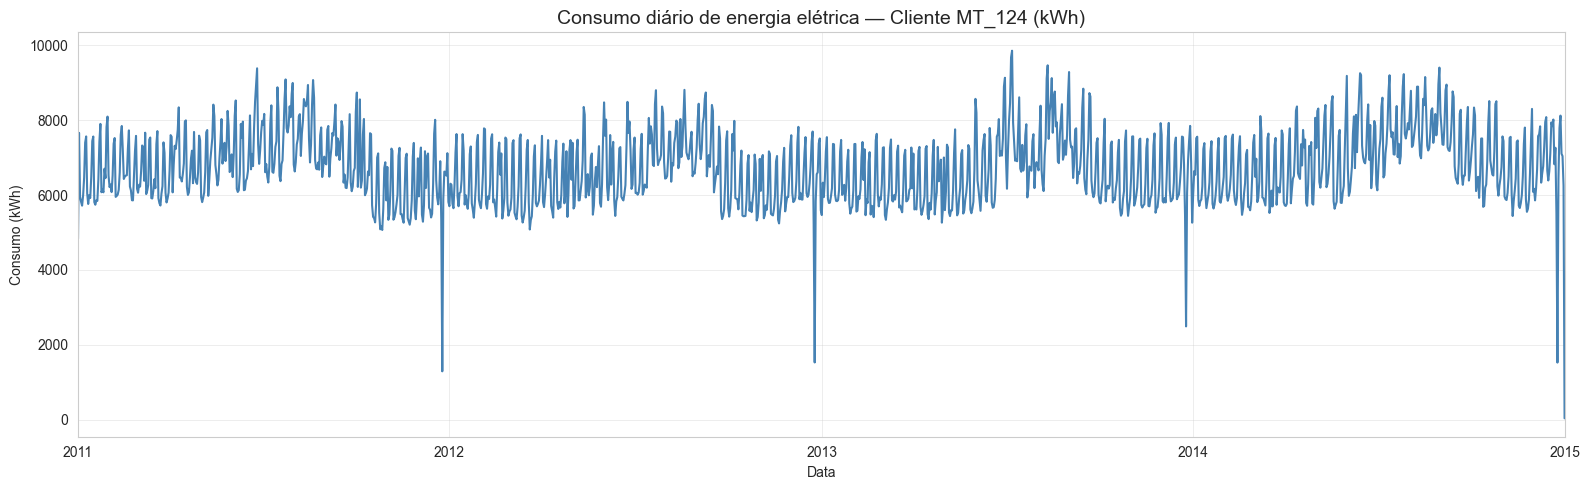

In [8]:
fig, ax = plt.subplots(figsize=(16, 5))
mt_124_daily['consumo_kwh'].plot(ax=ax, color='steelblue')
ax.set_title('Consumo diário de energia elétrica — Cliente MT_124 (kWh)', fontsize=14)
ax.set_xlabel('Data')
ax.set_ylabel('Consumo (kWh)')
plt.tight_layout()
plt.show()

## **Decomposição da série temporal**

A decomposição aditiva permite separar tendência, sazonalidade e resíduo. Utilizamos período sazonal de 365 dias (anual) para observar os componentes estruturais da série.

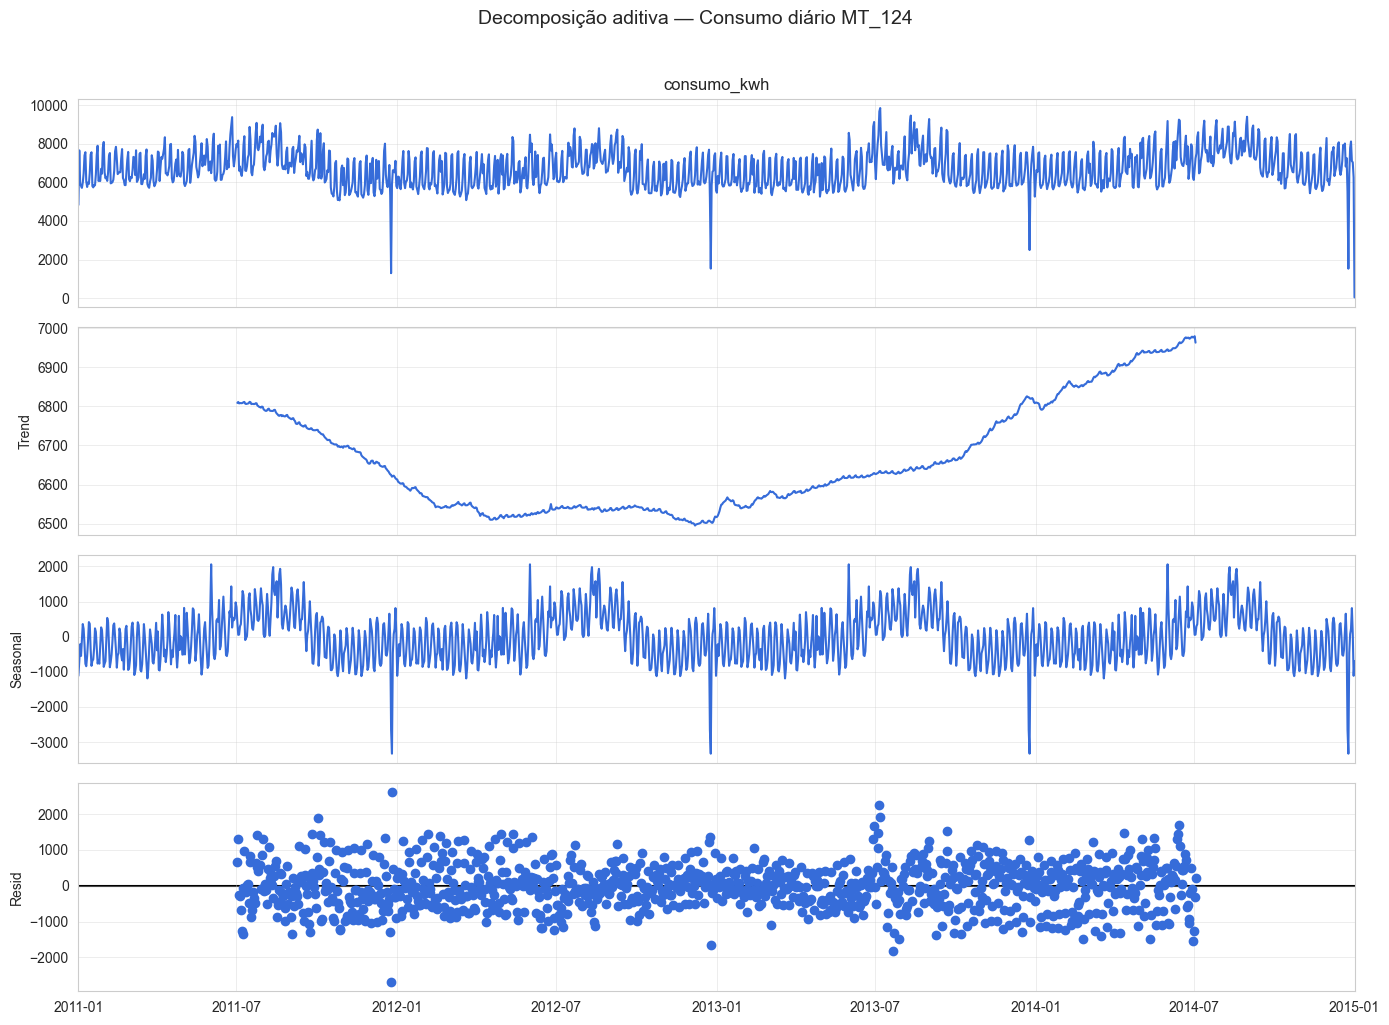

In [9]:
decomposicao = seasonal_decompose(
    mt_124_daily['consumo_kwh'],
    model='additive',
    period=365
)

fig = decomposicao.plot()
fig.set_size_inches(14, 10)
fig.suptitle('Decomposição aditiva — Consumo diário MT_124', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## **Análise sazonal por dia da semana e por mês**

- **Sazonalidade semanal:** valores mais altos em dias úteis e redução aos finais de semana.
- **Sazonalidade anual:** picos e vales repetidos em certas épocas do ano.

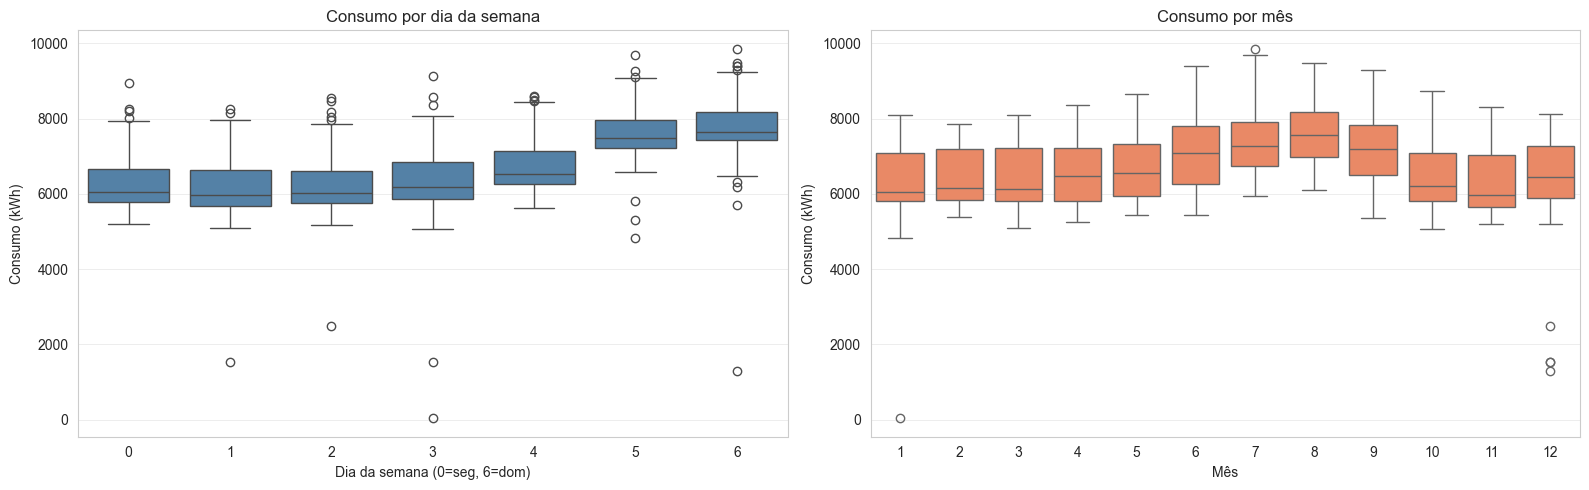

In [10]:
mt_124_daily['dia_semana'] = mt_124_daily.index.dayofweek
mt_124_daily['mes'] = mt_124_daily.index.month
mt_124_daily['dia_do_ano'] = mt_124_daily.index.dayofyear

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.boxplot(
    data=mt_124_daily, x='dia_semana', y='consumo_kwh',
    ax=axes[0], color='steelblue'
)
axes[0].set_title('Consumo por dia da semana')
axes[0].set_xlabel('Dia da semana (0=seg, 6=dom)')
axes[0].set_ylabel('Consumo (kWh)')

sns.boxplot(
    data=mt_124_daily, x='mes', y='consumo_kwh',
    ax=axes[1], color='coral'
)
axes[1].set_title('Consumo por mês')
axes[1].set_xlabel('Mês')
axes[1].set_ylabel('Consumo (kWh)')

plt.tight_layout()
plt.show()

## **Autocorrelação e autocorrelação parcial**

Os gráficos de ACF e PACF ajudam a identificar a dependência temporal e escolher parâmetros para modelos autorregressivos.

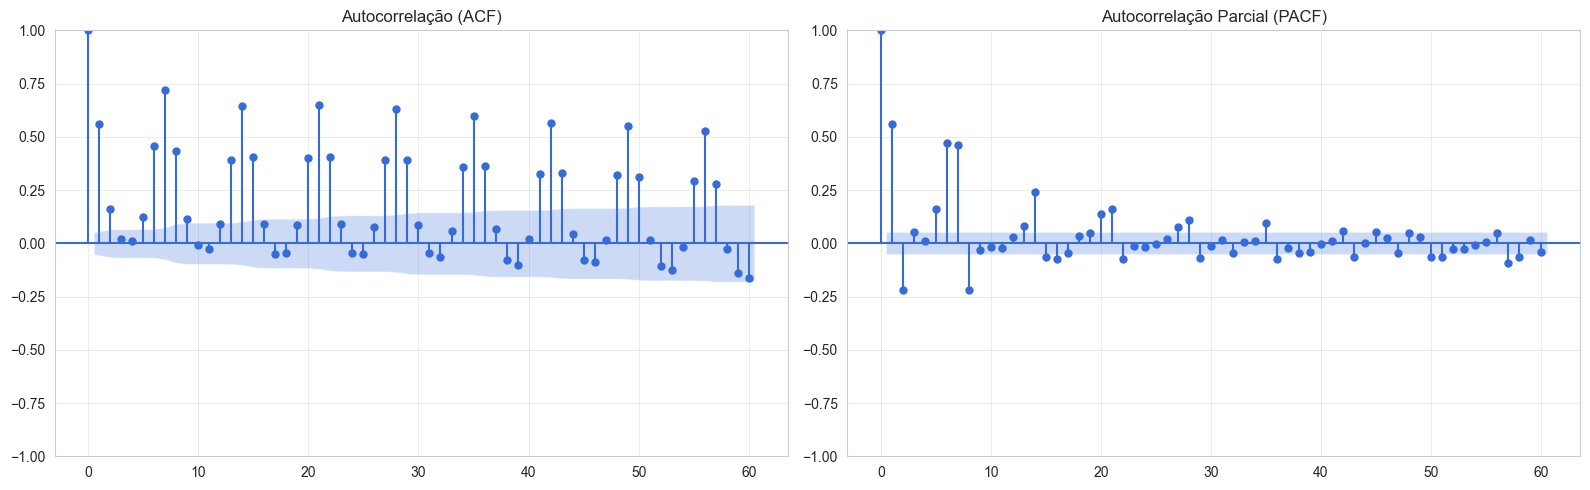

In [11]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

plot_acf(mt_124_daily['consumo_kwh'], lags=60, ax=axes[0])
axes[0].set_title('Autocorrelação (ACF)')

plot_pacf(mt_124_daily['consumo_kwh'], lags=60, ax=axes[1], method='ywm')
axes[1].set_title('Autocorrelação Parcial (PACF)')

plt.tight_layout()
plt.show()

## **Criação de atributos defasados (lags) e média móvel**

Para modelar dependências temporais, adicionamos:
- Lags de 1, 7 e 30 dias
- Média móvel de 7 e 30 dias

In [12]:
for lag in [1, 7, 30]:
    mt_124_daily[f'lag_{lag}'] = mt_124_daily['consumo_kwh'].shift(lag)

mt_124_daily['mm_7'] = mt_124_daily['consumo_kwh'].rolling(window=7).mean()
mt_124_daily['mm_30'] = mt_124_daily['consumo_kwh'].rolling(window=30).mean()

mt_124_daily.dropna(inplace=True)

print(f'Shape final: {mt_124_daily.shape}')
mt_124_daily.head(10)

Shape final: (1432, 9)


,consumo_kwh,dia_semana,mes,dia_do_ano,lag_1,lag_7,lag_30,mm_7,mm_30
datetime,,,,,,,,,
2011-01-31,6522.727273,0,1,31,8095.693780,6074.162679,4832.535885,6829.289132,6555.861244
2011-02-01,6210.526316,1,2,32,6522.727273,6141.148325,7660.287081,6839.200273,6507.535885
2011-02-02,6283.492823,2,2,33,6210.526316,6072.966507,5953.349282,6869.275461,6518.540670
2011-02-03,6078.947368,3,2,34,6283.492823,6703.349282,5818.181818,6780.075188,6527.232855
2011-02-04,6516.746411,4,2,35,6078.947368,6452.153110,5716.507177,6789.302802,6553.907496
2011-02-05,7369.617225,5,2,36,6516.746411,7816.985646,5990.430622,6725.393028,6599.880383
2011-02-06,7522.727273,6,2,37,7369.617225,8095.693780,6464.114833,6643.540670,6635.167464
2011-02-07,5950.956938,0,2,38,7522.727273,6522.727273,7399.521531,6561.859193,6586.881978
2011-02-08,5976.076555,1,2,39,5950.956938,6210.526316,7565.789474,6528.366370,6533.891547


## **Divisão em treino e teste**

Para respeitar a ordem temporal, utilizamos 2011–2013 como treino e 2014 como teste.

Treino: 2011-01-31 a 2013-12-31 — 1066 amostras
Teste:  2014-01-01 a 2015-01-01 — 366 amostras


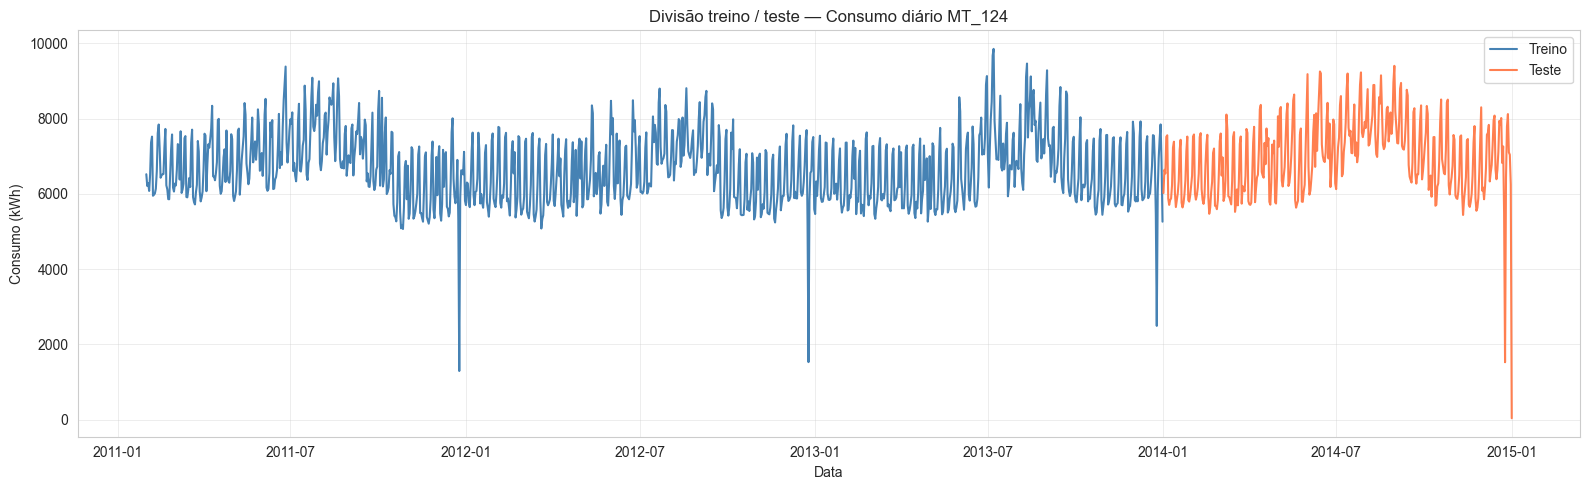

In [13]:
treino = mt_124_daily.loc[:'2013-12-31']
teste = mt_124_daily.loc['2014-01-01':]

print(f'Treino: {treino.index.min().date()} a {treino.index.max().date()} — {len(treino)} amostras')
print(f'Teste:  {teste.index.min().date()} a {teste.index.max().date()} — {len(teste)} amostras')

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(treino['consumo_kwh'], label='Treino', color='steelblue')
ax.plot(teste['consumo_kwh'], label='Teste', color='coral')
ax.set_title('Divisão treino / teste — Consumo diário MT_124')
ax.set_xlabel('Data')
ax.set_ylabel('Consumo (kWh)')
ax.legend()
plt.tight_layout()
plt.show()

## **Resumo estatístico do treino**

In [14]:
treino['consumo_kwh'].describe()

count    1066.000000
mean     6662.566092
std       939.850647
min      1291.866029
25%      5906.100478
50%      6526.315789
75%      7353.767943
max      9855.263158
Name: consumo_kwh, dtype: float64

## **Discussão e conclusões da EDA**

- **Qualidade dos dados:** o dataset original não apresenta faltantes, mas os registros em dias de mudança de horário de verão exigem atenção. Como a agregação diária soma as medições, tais anomalias tendem a se diluir, mas valores zero ou excessivamente altos foram verificados e tratados por interpolação.
- **Simplificações e recortes:** ao selecionar apenas o cliente MT_124 e passar para frequência diária, reduz-se a complexidade e torna-se possível conduzir uma análise aprofundada dentro do tempo disponível. Essa escolha implica abrir mão de variabilidade intradiária e do comportamento dos demais clientes, porém facilita a construção de modelos e a explicação dos resultados.
- **Transformações e junções:** além da conversão de kW para kWh e da agregação diária, a engenharia de features é essencial para capturar dependências temporais. Foram criados lags de 1, 7 e 30 dias, médias móveis de 7 e 30 dias, e variáveis sazonais (dia da semana, mês, dia do ano).
- **Padrões identificados:** o consumo elétrico diário apresenta tendência crescente e padrões sazonais claros (semanal e anual). A decomposição aditiva confirma esses componentes, e os gráficos de ACF/PACF evidenciam forte dependência temporal, especialmente com lag 7 (sazonalidade semanal).
- **Divisão temporal:** o treino cobre 2011–2013 e o teste cobre 2014, respeitando a ordem cronológica e evitando data leakage.

# **Modelo Base**

Aplicação de modelos iniciais para previsão do consumo diário de energia elétrica do cliente MT_124. Primeiro definimos funções de avaliação e em seguida aplicamos modelos de baseline (persistência e média móvel) e um modelo estatístico (SARIMA).

## **Funções de métricas de avaliação**

Utilizaremos as seguintes métricas para comparar os modelos:
- **MAE** (Mean Absolute Error): erro médio absoluto
- **RMSE** (Root Mean Squared Error): raiz do erro quadrático médio
- **MAPE** (Mean Absolute Percentage Error): erro percentual médio absoluto

In [18]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

def calcular_metricas(y_true, y_pred, nome_modelo):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    return {
        'Modelo': nome_modelo,
        'MAE': round(mae, 2),
        'RMSE': round(rmse, 2),
        'MAPE (%)': round(mape, 2)
    }

y_test = teste['consumo_kwh']
resultados = []

## **Modelo 1 — Persistência (Naive)**

O modelo de persistência prevê que o consumo de amanhã será igual ao de hoje (ŷ_t = y_{t-1}). É o baseline mais simples e serve como referência para avaliar se modelos mais sofisticados agregam valor preditivo.

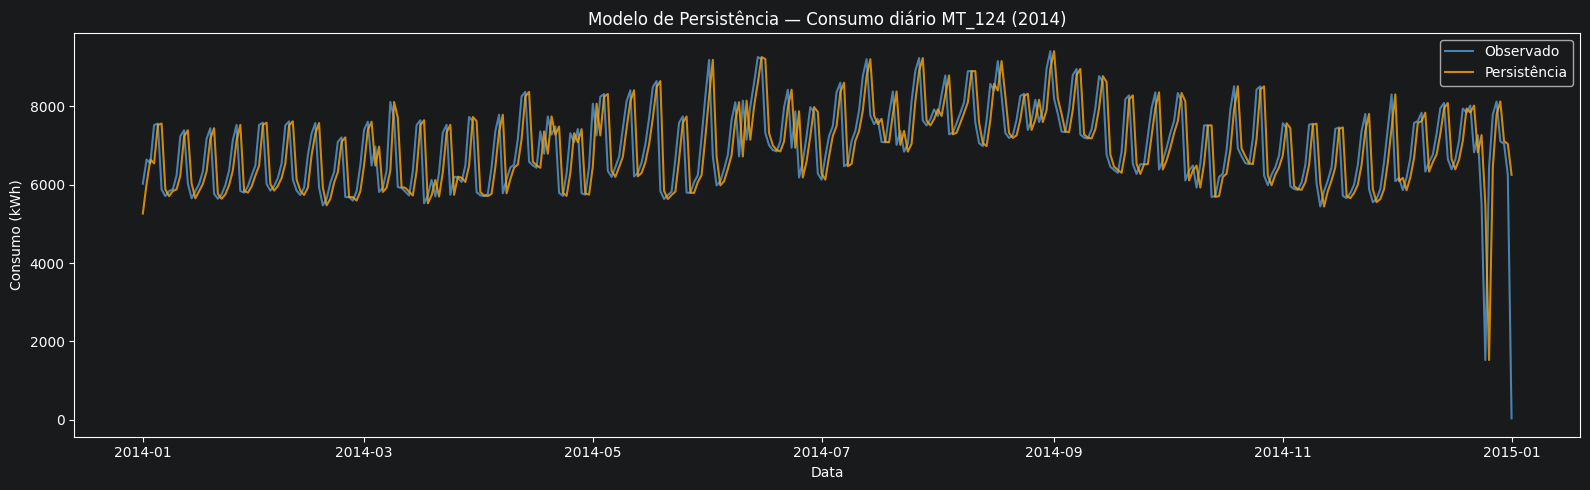

In [19]:
y_persistencia = treino['consumo_kwh'].iloc[-1]
y_pred_persistencia = pd.Series(
    [treino['consumo_kwh'].iloc[-1]] * len(teste),
    index=teste.index
)

y_test_shifted = teste['consumo_kwh'].shift(1)
y_pred_naive = y_test_shifted.copy()
y_pred_naive.iloc[0] = treino['consumo_kwh'].iloc[-1]
y_pred_naive = y_pred_naive

resultados.append(calcular_metricas(y_test, y_pred_naive, 'Persistência (lag-1)'))

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(teste.index, y_test, label='Observado', color='steelblue')
ax.plot(teste.index, y_pred_naive, label='Persistência', color='orange', alpha=0.8)
ax.set_title('Modelo de Persistência — Consumo diário MT_124 (2014)')
ax.set_xlabel('Data')
ax.set_ylabel('Consumo (kWh)')
ax.legend()
plt.tight_layout()
plt.show()

## **Modelo 2 — Média Móvel (7 dias)**

O modelo de média móvel simples prevê o consumo do próximo dia como a média dos últimos 7 dias observados. Captura parcialmente a suavidade semanal dos dados.

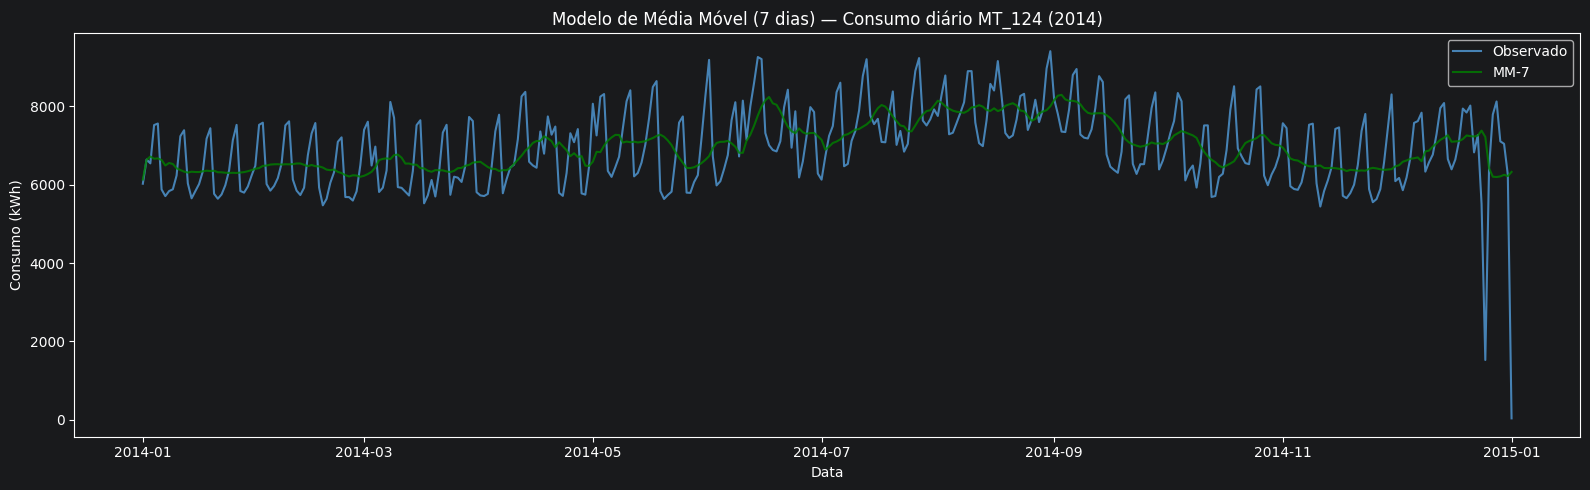

In [20]:
serie_completa = pd.concat([treino['consumo_kwh'], teste['consumo_kwh']])
y_pred_mm7 = serie_completa.shift(1).rolling(window=7).mean()
y_pred_mm7 = y_pred_mm7.loc[teste.index]
y_pred_mm7 = y_pred_mm7.dropna()

y_test_mm7 = y_test.loc[y_pred_mm7.index]
resultados.append(calcular_metricas(y_test_mm7, y_pred_mm7, 'Média Móvel (7 dias)'))

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(y_test.index, y_test, label='Observado', color='steelblue')
ax.plot(y_pred_mm7.index, y_pred_mm7, label='MM-7', color='green', alpha=0.8)
ax.set_title('Modelo de Média Móvel (7 dias) — Consumo diário MT_124 (2014)')
ax.set_xlabel('Data')
ax.set_ylabel('Consumo (kWh)')
ax.legend()
plt.tight_layout()
plt.show()

## **Modelo 3 — SARIMA**

O modelo SARIMA (Seasonal ARIMA) estende o ARIMA ao incorporar componentes sazonais. Dada a clara sazonalidade semanal identificada na EDA, utilizamos ordem sazonal com s=7. Os parâmetros iniciais foram definidos com base na análise de ACF/PACF e serão refinados em etapas posteriores.

In [21]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller

resultado_adf = adfuller(treino['consumo_kwh'])
print(f'Teste ADF — Estatística: {resultado_adf[0]:.4f}')
print(f'p-valor: {resultado_adf[1]:.4f}')
if resultado_adf[1] < 0.05:
    print('A série é estacionária (rejeita H0).')
else:
    print('A série NÃO é estacionária (não rejeita H0). É necessário diferenciação.')

Teste ADF — Estatística: -2.6500
p-valor: 0.0831
A série NÃO é estacionária (não rejeita H0). É necessário diferenciação.


In [22]:
modelo_sarima = SARIMAX(
    treino['consumo_kwh'],
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False
)
resultado_sarima = modelo_sarima.fit(disp=False)
print(resultado_sarima.summary())

                                     SARIMAX Results                                     
Dep. Variable:                       consumo_kwh   No. Observations:                 1066
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 7)   Log Likelihood               -8007.904
Date:                           Sat, 25 Apr 2026   AIC                          16025.809
Time:                                   10:59:09   BIC                          16050.587
Sample:                               01-31-2011   HQIC                         16035.204
                                    - 12-31-2013                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4184      0.018     22.690      0.000       0.382       0.455
ma.L1         -0.9222      0.017    -54.715

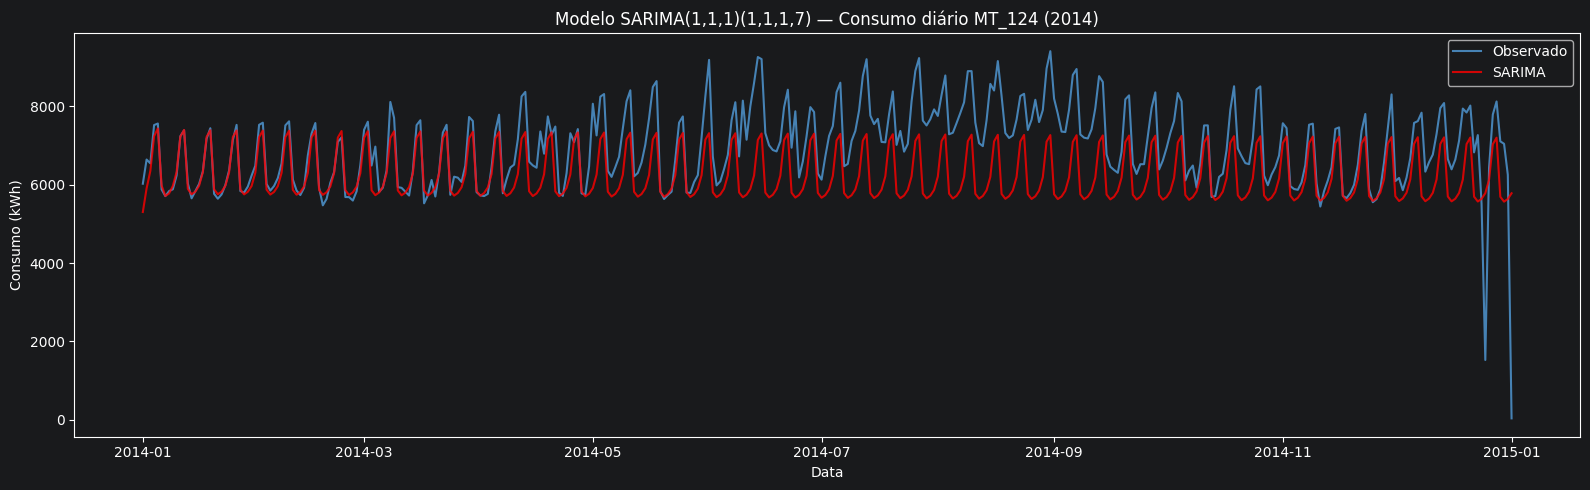

In [23]:
y_pred_sarima = resultado_sarima.forecast(steps=len(teste))
y_pred_sarima.index = teste.index

resultados.append(calcular_metricas(y_test, y_pred_sarima, 'SARIMA(1,1,1)(1,1,1,7)'))

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(y_test.index, y_test, label='Observado', color='steelblue')
ax.plot(y_test.index, y_pred_sarima, label='SARIMA', color='red', alpha=0.8)
ax.set_title('Modelo SARIMA(1,1,1)(1,1,1,7) — Consumo diário MT_124 (2014)')
ax.set_xlabel('Data')
ax.set_ylabel('Consumo (kWh)')
ax.legend()
plt.tight_layout()
plt.show()

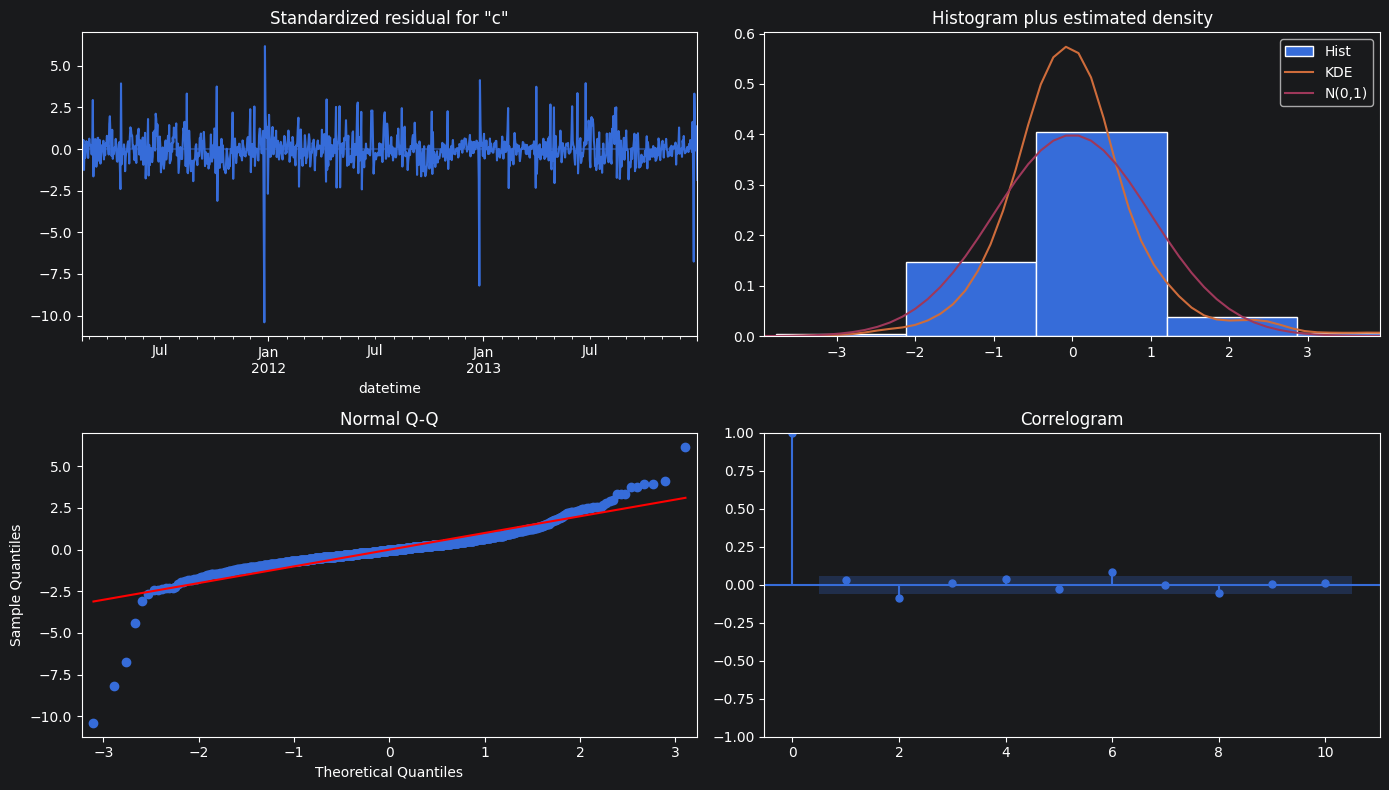

In [24]:
resultado_sarima.plot_diagnostics(figsize=(14, 8))
plt.tight_layout()
plt.show()

## **Comparação dos modelos**

Tabela comparativa das métricas de avaliação dos modelos baseline aplicados.

In [25]:
df_resultados = pd.DataFrame(resultados)
display(df_resultados)

,Modelo,MAE,RMSE,MAPE (%)
0,Persistência (lag-1),645.41,947.96,57.07
1,Média Móvel (7 dias),716.28,922.10,58.64
2,"SARIMA(1,1,1)(1,1,1,7)",797.64,1072.47,54.82


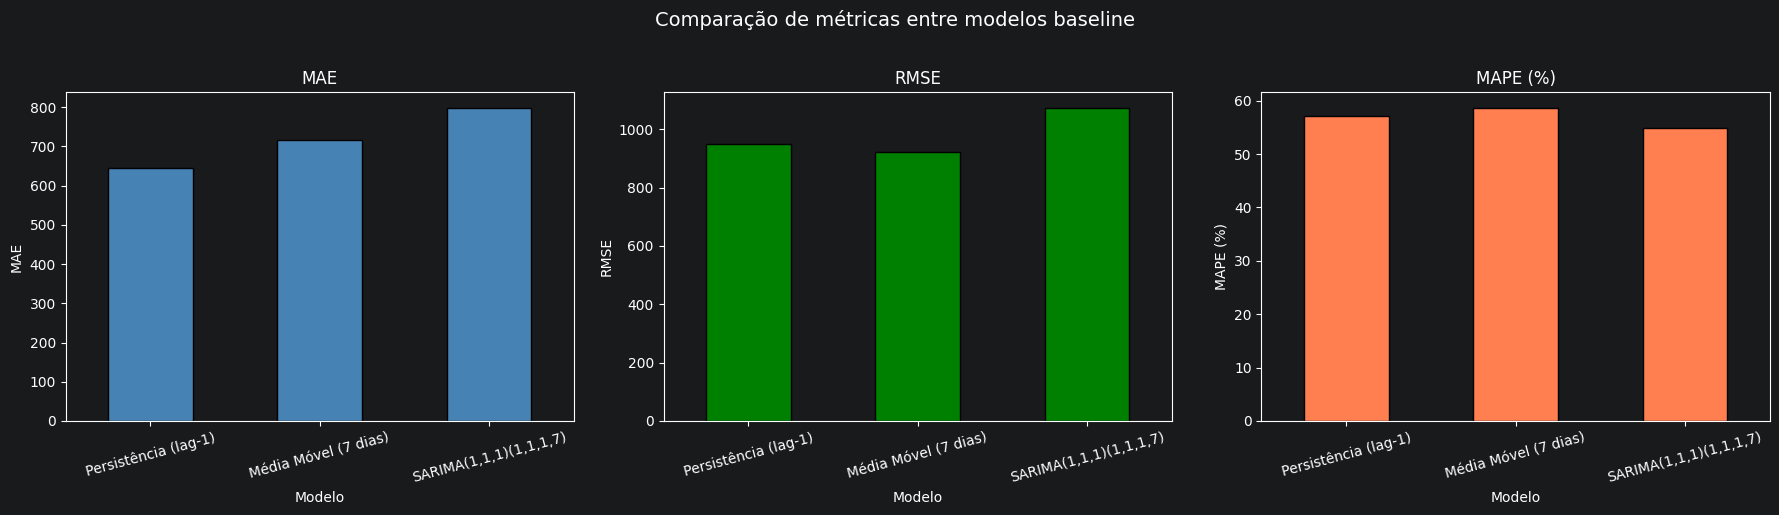

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metricas = ['MAE', 'RMSE', 'MAPE (%)']
cores = ['steelblue', 'green', 'coral']

for ax, metrica, cor in zip(axes, metricas, cores):
    df_resultados.plot(
        x='Modelo', y=metrica, kind='bar', ax=ax, color=cor, legend=False, edgecolor='black'
    )
    ax.set_title(metrica)
    ax.set_ylabel(metrica)
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Comparação de métricas entre modelos baseline', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## **Análise dos resultados**

Os modelos baseline servem como referência para avaliar se abordagens mais sofisticadas agregam valor preditivo. Observa-se que:

- O modelo de **persistência** é o mais simples e estima que o consumo de amanhã será igual ao de hoje. Captura bem a tendência de curto prazo, mas não modela sazonalidade.
- A **média móvel de 7 dias** suaviza variações diárias e capta parte da sazonalidade semanal, tendendo a subestimar picos.
- O **SARIMA** incorpora explicitamente a estrutura autorregressiva e a sazonalidade semanal (s=7), podendo oferecer previsões mais ajustadas.

Os resultados destes modelos serão utilizados como baseline para comparação com modelos de aprendizado de máquina (Random Forest, Prophet, etc.) nas próximas entregas.

# **Cronograma**

| Período | Fase | Atividades | Entregas |
|--------|------|------------|----------|
| 29/03 a 07/04 | Entendimento do problema e coleta de dados | Definição do objetivo e horizonte de previsão; coleta do dataset; leitura e ingestão dos dados | Base de dados carregada e estruturada |
| 08/04 a 14/04 | Pré-processamento | Conversão de timestamp; tratamento de valores nulos; padronização de tipos; ordenação temporal | Dataset limpo e consistente |
| 15/04 a 18/04 | Transformação e análise exploratória | Agregação da série para nível diário; criação de variáveis (lags, médias móveis, variáveis sazonais); análise de tendência, sazonalidade e outliers | Dataset enriquecido e gráficos exploratórios |
| 19/04 a 24/04 | Modelagem inicial | Implementação de modelo baseline; aplicação de ARIMA/SARIMA; geração de previsões iniciais | Modelos iniciais e primeiros resultados |
| 26/04 | Entrega parcial | Consolidação do pipeline; apresentação da análise exploratória; apresentação dos modelos iniciais e métricas preliminares | Entrega parcial do projeto |
| 27/04 a 10/05 | Modelagem avançada | Implementação de Random Forest; ajuste de hiperparâmetros; testes comparativos entre modelos | Modelos aprimorados |
| 11/05 a 18/05 | Avaliação | Cálculo das métricas (MAE, RMSE, MAPE); comparação entre modelos; análise de erros | Tabela comparativa e análise de desempenho |
| 19/05 a 28/05 | Consolidação final | Seleção do melhor modelo; elaboração da justificativa técnica; redação e revisão do relatório final | Relatório final estruturado |
| 31/05 | Entrega final | Entrega do projeto completo com resultados, análises e conclusões | Projeto final entregue |

# **Referências**

IEEE POWER & ENERGY SOCIETY.
Electric load forecasting. Disponível em: https://pes.ieee.org. Acesso em: 25 mar. 2026.

KAGGLE.
Electricity Load Diagrams 2011–2014 Dataset. Disponível em: https://www.kaggle.com. Acesso em: 25 mar. 2026.

SCIKIT-LEARN.
Machine Learning in Python – Random Forest documentation. Disponível em: https://scikit-learn.org. Acesso em: 25 mar. 2026.

TENSORFLOW.
Time series forecasting with LSTM. Disponível em: https://www.tensorflow.org. Acesso em: 25 mar. 2026.



In [27]:
#@title **Avaliação**
EDA_e_preprocessamento = 10 #@param {type:"slider", min:0, max:10, step:1}

Modelo_base = 10 #@param {type:"slider", min:0, max:10, step:1}

In [28]:
#@title **Nota Final**
nota = 0.50*EDA_e_preprocessamento + 0.50*Modelo_base

print(f'Nota final do trabalho {nota :.1f}')

import numpy as np
import pandas as pd

alunos = pd.DataFrame()

lista_nome = []

for i in range(1,6):
  exec("if Aluno" + str(i) + " !='None':  lista = Aluno" + str(i) + ".split(','); lista_nome.append(lista[0]);")

alunos['nome'] = lista_nome
alunos['nota'] = np.round(nota,1)
print()
display(alunos)

Nota final do trabalho 10.0



,nome,nota
0,Bianca Rezk de Angelo Correa,10.0
1,Bruna Fagundes Pereira Queiroz,10.0
2,Caio Cesar Teixeira Rocha,10.0
3,Livya Kaizer de Albuquerque,10.0
4,Lucas Feo Mazzei,10.0
